# Analysis of CPDs for all screens

CPD = cumulative population doublings

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

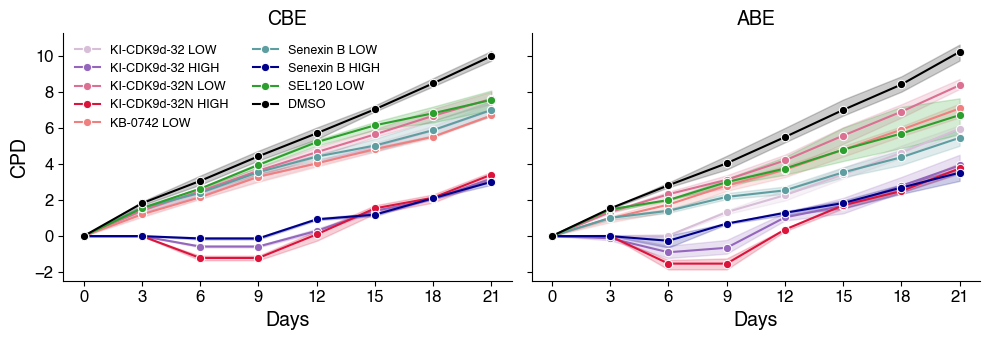

In [ ]:
c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'CBE_screen')


c1.loc[(c1['Drug']=='KI-CDK9d-32') & (c1['Concentration (nM)']==100), 'Condition'] = 'KI-CDK9d-32 LOW'
c1.loc[(c1['Drug']=='KI-CDK9d-32') & (c1['Concentration (nM)']==1000), 'Condition'] = 'KI-CDK9d-32 HIGH'
c1.loc[(c1['Drug']=='KI-CDK9d-32N') & (c1['Concentration (nM)']==1250), 'Condition'] = 'KI-CDK9d-32N LOW'
c1.loc[(c1['Drug']=='KI-CDK9d-32N') & (c1['Concentration (nM)']==5000), 'Condition'] = 'KI-CDK9d-32N HIGH'
c1.loc[(c1['Drug']=='KB-0742') & (c1['Concentration (nM)']==1500), 'Condition'] = 'KB-0742 LOW'
c1.loc[(c1['Drug']=='KB-0742') & (c1['Concentration (nM)']==5000), 'Condition'] = 'KB-0742 HIGH'
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==1000), 'Condition'] = 'SY-5609 LOW'
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==2500), 'Condition'] = 'SY-5609 HIGH'
c1.loc[(c1['Drug']=='Senexin B') & (c1['Concentration (nM)']==2000), 'Condition'] = 'Senexin B LOW'
c1.loc[(c1['Drug']=='Senexin B') & (c1['Concentration (nM)']==15000), 'Condition'] = 'Senexin B HIGH'
c1.loc[(c1['Drug']=='SEL120') & (c1['Concentration (nM)']==4000), 'Condition'] = 'SEL120 LOW'
c1.loc[(c1['Drug']=='SEL120') & (c1['Concentration (nM)']==8000), 'Condition'] = 'SEL120 HIGH'
c1.loc[(c1['Drug']=='DMSO'), 'Condition'] = 'DMSO'


exc = ['SEL120 HIGH', 'SY-5609 HIGH', 'SY-5609 LOW', 'KB-0742 HIGH']
c1 = c1[~c1['Condition'].isin(exc)].dropna(subset='Condition').reset_index(drop=True)

c_dict = {'DMSO':'black', 
'KB-0742 LOW':'lightcoral',
'KI-CDK9d-32 HIGH':'tab:purple',
'KI-CDK9d-32 LOW':'thistle', 
'KI-CDK9d-32N HIGH':'crimson', 
'KI-CDK9d-32N LOW':'palevioletred', 
'SEL120 LOW':'tab:green',
'Senexin B HIGH':'darkblue', 
'Senexin B LOW':'cadetblue'}

c1['color'] = [c_dict[i] for i in c1['Condition']]


fig, ax = plt.subplots(1,2,figsize=(10,3.5), sharey=True, sharex=True)
sns.lineplot(data=c1, x='Days Post-Treatment', y='CPDs', hue='Condition', marker='o', ax=ax[0],palette=c_dict)

c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'ABE_screen')


c1.loc[(c1['Drug']=='KI-CDK9d-32') & (c1['Concentration (nM)']==100), 'Condition'] = 'KI-CDK9d-32 LOW'
c1.loc[(c1['Drug']=='KI-CDK9d-32') & (c1['Concentration (nM)']==1000), 'Condition'] = 'KI-CDK9d-32 HIGH'
c1.loc[(c1['Drug']=='KI-CDK9d-32N') & (c1['Concentration (nM)']==1250), 'Condition'] = 'KI-CDK9d-32N LOW'
c1.loc[(c1['Drug']=='KI-CDK9d-32N') & (c1['Concentration (nM)']==5000), 'Condition'] = 'KI-CDK9d-32N HIGH'
c1.loc[(c1['Drug']=='KB-0742') & (c1['Concentration (nM)']==1500), 'Condition'] = 'KB-0742 LOW'
c1.loc[(c1['Drug']=='KB-0742') & (c1['Concentration (nM)']==5000), 'Condition'] = 'KB-0742 HIGH'
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==1000), 'Condition'] = 'SY-5609 LOW'
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==2500), 'Condition'] = 'SY-5609 HIGH'
c1.loc[(c1['Drug']=='Senexin B') & (c1['Concentration (nM)']==2000), 'Condition'] = 'Senexin B LOW'
c1.loc[(c1['Drug']=='Senexin B') & (c1['Concentration (nM)']==15000), 'Condition'] = 'Senexin B HIGH'
c1.loc[(c1['Drug']=='SEL120') & (c1['Concentration (nM)']==4000), 'Condition'] = 'SEL120 LOW'
c1.loc[(c1['Drug']=='SEL120') & (c1['Concentration (nM)']==8000), 'Condition'] = 'SEL120 HIGH'
c1.loc[(c1['Drug']=='DMSO'), 'Condition'] = 'DMSO'


exc = ['SEL120 HIGH', 'SY-5609 HIGH', 'SY-5609 LOW', 'KB-0742 HIGH']
c1 = c1[~c1['Condition'].isin(exc)].dropna(subset='Condition').reset_index(drop=True)
c1['color'] = [c_dict[i] for i in c1['Condition']]

sns.lineplot(data=c1, x='Days Post-Treatment', y='CPDs', hue='Condition', marker='o', ax=ax[1], palette=c_dict)

ax[0].set_xticks(list(range(0,22,3)))

ax[0].set_ylabel('CPD', fontsize=14)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel('Days', fontsize=14)
ax[1].set_xlabel('Days', fontsize=14)

ax[0].set_title('CBE', fontsize=14)
ax[1].set_title('ABE', fontsize=14)

ax[0].legend(fontsize=9, ncols=2, loc='upper left', frameon=False)
ax[1].get_legend().remove()

fig.tight_layout()
#fig.savefig('../../figures/CPD_s1.pdf', transparent=True)

In [33]:
list(range(0,22,3))

[0, 3, 6, 9, 12, 15, 18, 21]

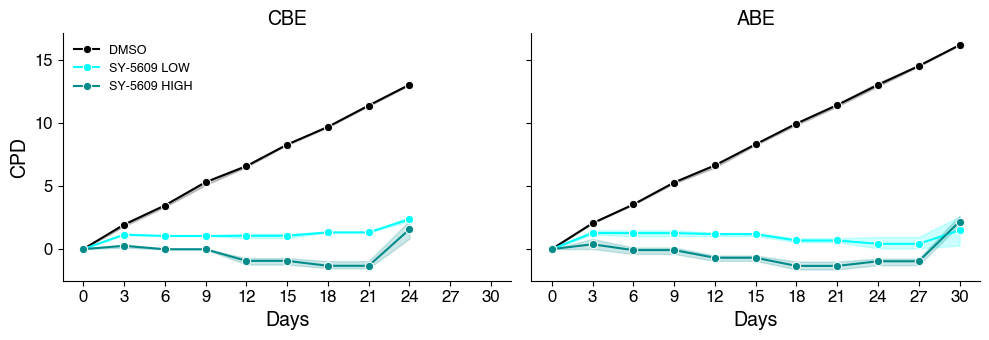

In [ ]:
c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'CBE SY-5609')
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==10), 'Condition'] = 'SY-5609 LOW'
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==100), 'Condition'] = 'SY-5609 HIGH'
c1.loc[(c1['Drug']=='DMSO'), 'Condition'] = 'DMSO'


sy_cbe = c1.fillna(0)
sy_cbe = sy_cbe[sy_cbe['Drug']!=0]


c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'ABE SY-5609')
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==10), 'Condition'] = 'SY-5609 LOW'
c1.loc[(c1['Drug']=='SY-5609') & (c1['Concentration (nM)']==100), 'Condition'] = 'SY-5609 HIGH'
c1.loc[(c1['Drug']=='DMSO'), 'Condition'] = 'DMSO'

sy_abe = c1.fillna(0)
sy_abe = sy_abe[sy_abe['Drug']!=0]

fig, ax = plt.subplots(1,2,figsize=(10,3.5), sharey=True, sharex=True)

c_dict = {'DMSO':'black',
        'SY-5609 LOW':'cyan',
          'SY-5609 HIGH':'darkcyan'}
sns.lineplot(data=sy_cbe, x='Days Post-Treatment', y='CPDs', hue='Condition', marker='o', ax=ax[0],palette=c_dict)
sns.lineplot(data=sy_abe, x='Days Post-Treatment', y='CPDs', hue='Condition', marker='o', ax=ax[1], palette=c_dict)

ax[0].set_xticks(list(range(0,31,3)))

ax[0].set_ylabel('CPD', fontsize=14)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel('Days', fontsize=14)
ax[1].set_xlabel('Days', fontsize=14)

ax[0].set_title('CBE', fontsize=14)
ax[1].set_title('ABE', fontsize=14)

ax[0].legend(fontsize=9, ncols=1, loc='upper left', frameon=False)
ax[1].get_legend().remove()

fig.tight_layout()

fig.tight_layout()
#fig.savefig('../../figures/CPD_sY.pdf', transparent=True)


In [97]:
sy_abe

,Date,Days Post-Transduction,Days Post-Treatment,Selection Agent,Drug,Concentration (nM),Actual concentration replated (nM),Replicate,Plate # /Format,Cell Count (millions),...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Condition
0,2025-02-15,7,NaN,NaN,NaN,NaN,NaN,1,2x 15-cm plates,~12 MM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-15,7,NaN,NaN,NaN,NaN,NaN,2,2x 15-cm plates,~12 MM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-15,7,NaN,NaN,NaN,NaN,NaN,3,2x 15-cm plates,~12 MM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-02-16,8,NaN,NaN,NaN,NaN,NaN,1,2x 15-cm plate,~12 MM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-02-16,8,NaN,NaN,NaN,NaN,NaN,2,2x 15-cm plate,~12 MM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,2025-03-18,38,30.0,NaN,SY-5609,10.0,0.0,2,2x 15-cm plate,4.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SY-5609 LOW
101,2025-03-18,38,30.0,NaN,SY-5609,10.0,0.0,3,2x 15-cm plate,1.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SY-5609 LOW
102,2025-03-18,38,30.0,NaN,SY-5609,100.0,0.0,1,2x 15-cm plate,17.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SY-5609 HIGH
103,2025-03-18,38,30.0,NaN,SY-5609,100.0,0.0,2,2x 15-cm plate,10.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SY-5609 HIGH


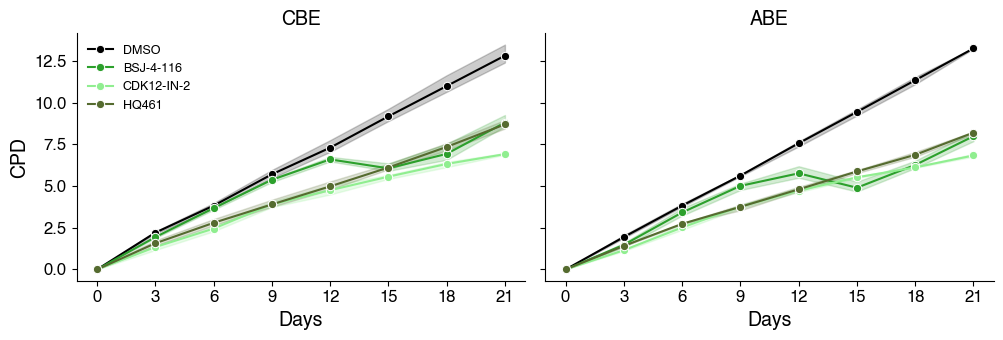

In [ ]:
c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'CBE_CDK12_13')

c1 = c1[c1['Drug']!='NONE']
c12_cbe = c1

c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'ABE_CDK12_13')

c1 = c1[c1['Drug']!='NONE']
c12_abe = c1

fig, ax = plt.subplots(1,2,figsize=(10,3.5), sharey=True, sharex=True)


palette = ['darkolivegreen','tab:green', 'lightgreen', 'black']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2', 'DMSO']

c_dict = dict(zip(hue_order, palette))

sns.lineplot(data=c12_cbe, x='Days Post-Treatment', y='CPDs', hue='Drug', marker='o', ax=ax[0], palette=c_dict)
sns.lineplot(data=c12_abe, x='Days Post-Treatment', y='CPDs', hue='Drug', marker='o', ax=ax[1], palette=c_dict)

ax[0].set_xticks(list(range(0,22,3)))

ax[0].set_ylabel('CPD', fontsize=14)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel('Days', fontsize=14)
ax[1].set_xlabel('Days', fontsize=14)

ax[0].set_title('CBE', fontsize=14)
ax[1].set_title('ABE', fontsize=14)

ax[0].legend(fontsize=9, ncols=1, loc='upper left', frameon=False)
ax[1].get_legend().remove()

fig.tight_layout()
#fig.savefig('../../figures/CPD_s2.pdf', transparent=True)




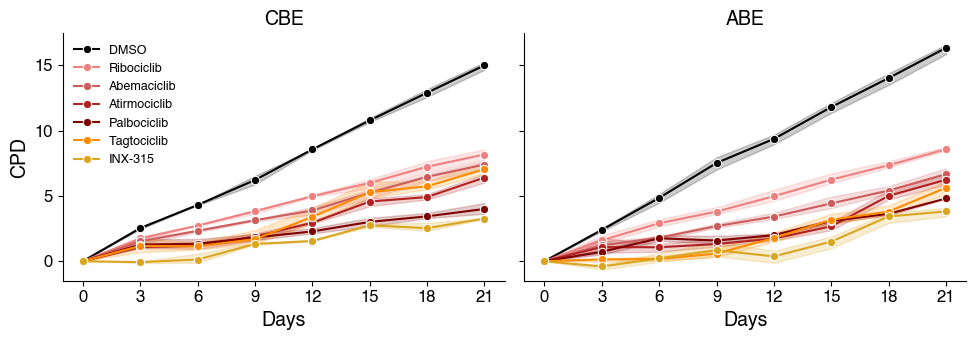

In [96]:
c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'CBE_CDK2_4_6')

c1 = c1[c1['Drug']!='NONE']
c2_cbe = c1

c1 = pd.read_excel('../../source_data/08_screening_data_cell_counts/CDK_BE_cell_counts.xlsx', 'ABE_CDK2_4_6')

c1 = c1[c1['Drug']!='NONE']
c2_abe = c1

palette = ['black', 'lightcoral', 'indianred', 'firebrick', 'maroon', 'darkorange', 'goldenrod',]
hue_order = ['DMSO', 'Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315',]
c_dict = dict(zip(hue_order, palette))


fig, ax = plt.subplots(1,2,figsize=(10,3.5), sharey=True, sharex=True)
sns.lineplot(data=c2_cbe, x='Days Post-Treatment', y='CPDs', hue='Drug', marker='o', ax=ax[0],hue_order=hue_order, palette=c_dict)
sns.lineplot(data=c2_abe, x='Days Post-Treatment', y='CPDs', hue='Drug', marker='o', ax=ax[1],hue_order=hue_order, palette=c_dict)

ax[0].set_xticks(list(range(0,22,3)))

ax[0].set_ylabel('CPD', fontsize=14)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel('Days', fontsize=14)
ax[1].set_xlabel('Days', fontsize=14)

ax[0].set_title('CBE', fontsize=14)
ax[1].set_title('ABE', fontsize=14)

ax[0].legend(fontsize=9, ncols=1, loc='upper left', frameon=False)
ax[1].get_legend().remove()

fig.tight_layout()
#fig.savefig('../../figures/CPD_s3.pdf', transparent=True)
